## 環境設置

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Case-08.1:矩形單筋梁撓曲設計

依 [ROADMAP.md](../ROADMAP.md) 規劃,這是 **Case-08 系列**(鋼筋混凝土
入門到耐震設計配筋、不含 pushover)的起手式。

**這一步要解決的問題**:`case03_6`、`case03_7`、`case06_5` 一路以來,
柱跟梁的配筋都是**假設 rho=2%**,再檢查這個假設夠不夠用——從來沒有
真的從設計彎矩 Mu 反算出應該配多少鋼筋。Case-08 系列要把這個洞補起來,
從最基本的矩形單筋梁開始,08.8 會接回 `case03_7` 的 `design_loop`,
把固定 rho 換成這裡做出來的真實設計函式。

**定位**:這是 Design(配筋設計)案例,不含非線性分析/pushover——
產出的是符合規範強度設計法(《結構混凝土設計規範》第 21、22 章)的
配筋結果,可以直接被後續案例引用。

## 第 1 課:強度設計法公式

矩形單筋梁,拉力鋼筋降伏、混凝土壓應力用 Whitney 等效矩形應力塊簡化
(規範 22.2.2.4.1)。

**強度折減因數**(表 21.2.2):拉力控制斷面(εt ≥ 0.005)取 φ=0.9,
這裡先假設拉力控制,算完會反過來驗證 εt 是否真的 ≥0.005。

**係數 Rn 與需求鋼筋比**(標準強度設計法推導,由 Mu=φAsfy(d-a/2) 與
a=Asfy/(0.85f'cb) 消去 a 後解 As 的二次方程式得出):

$$R_n = \frac{M_u}{\phi b d^2}, \qquad
\rho = \frac{0.85f_c'}{f_y}\left(1-\sqrt{1-\frac{2R_n}{0.85f_c'}}\right)$$

**最小鋼筋比**(規範式 8.6.1.1,避免斷面開裂後立即脆性破壞):

$$\rho_{min} = \max\left(\frac{14}{f_y}, \frac{0.8\sqrt{f_c'}}{f_y}\right)$$

(以上兩式用規範原文傳統單位制:kgf/cm²、cm)

In [2]:
import os
if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
from rc_design import design_rebar

print("rc_design.design_rebar() 已從共用模組載入")

rc_design.design_rebar() 已從共用模組載入


## 第 2 課:設計案例

沿用之前對照過的案例(簡支梁 30×50cm, Wu=25kN/m, L=6m, 跨中
Mu=112.5kN-m),當作這個函式庫的標準測試案例——之後每次改函式,
都可以拿這組數字回歸測試。

In [3]:
CASE = dict(
    b_cm=30.0, h_cm=50.0, cover=4.0,
    fc=280.0, fy=4200.0,
)
Wu, L = 25.0, 6.0                       # 載重與跨度(用來推導Mu, 不是斷面本身的設計參數)
CASE['Mu_kNm'] = Wu*L**2/8

r = design_rebar(**CASE)

print(f"設計彎矩 Mu = {CASE['Mu_kNm']:.1f} kN-m")
print(f"有效深度 d = {r['d']:.2f} cm")
print(f"需求鋼筋比 rho_req = {r['rho_req']:.5f}  (rho_min = {r['rho_min']:.5f})")
print(f"需求 As = {r['As_req']:.2f} cm^2")
print(f"拉力應變 eps_t = {r['eps_t']:.4f}  ({'拉力控制 phi=0.9 成立' if r['eps_t']>=0.005 else '需調整phi'})")
print(f"\n選筋: {r['n_bars']}-{r['bar_size']}, As供給 = {r['As_provided']:.2f} cm^2")
print(f"排筋淨間距 = {r['clear_spacing']:.2f} cm")
print(f"phiMn供給 = {r['phiMn_provided']:.2f} kN-m  (需求Mu = {CASE['Mu_kNm']:.2f})")
print(f"使用率 = {r['utilization']:.1%}")

assert r['phiMn_provided'] >= CASE['Mu_kNm'], "配筋強度不足, 設計錯誤"
assert r['eps_t'] >= 0.005, "非拉力控制斷面"
assert r['clear_spacing'] >= max(r['bar_d'], 2.5), "排筋間距不足"
print("\n[PASS] 三項檢核(強度足夠/拉力控制/排筋間距)全部通過")


設計彎矩 Mu = 112.5 kN-m
有效深度 d = 43.80 cm
需求鋼筋比 rho_req = 0.00554  (rho_min = 0.00333)
需求 As = 7.29 cm^2
拉力應變 eps_t = 0.0231  (拉力控制 phi=0.9 成立)

選筋: 2-#7(D22), As供給 = 7.74 cm^2
排筋淨間距 = 15.66 cm
phiMn供給 = 119.17 kN-m  (需求Mu = 112.50)
使用率 = 94.4%

[PASS] 三項檢核(強度足夠/拉力控制/排筋間距)全部通過


## 第 3 課:交叉驗證——用應變相容法反解 As

`design_rebar()` 用的是規範標準做法(Whitney 等效矩形應力塊 + 代數解),
這裡用**另一個獨立方法**——應變相容法(平面保持平面 + 力平衡,對中性軸
位置 c 做二分搜尋)反過來解:「要多少 As 才能剛好讓 φMn=Mu」,拿來驗證
公式解對不對。

理論上兩者應該完全一致(Whitney 應力塊在鋼筋降伏的前提下,本來就是
應變相容法在特定簡化假設下的封閉解,不是兩個獨立的物理模型)——
如果兩者對不上,代表 `design_rebar()` 或這裡的反解邏輯有 bug,不是
"合理的方法論差異"。

In [4]:
def find_As_by_strain_compat(Mu_kNm, b_cm, d_cm, fc=280.0, fy=4200.0, Es=2.0e6,
                              phi_target=0.9, beta1=0.85, eps_cu=0.003):
    '''給定Mu, 用應變相容法反解需要多少As(對中性軸c二分搜尋), 拿來跟公式解交叉驗證'''
    eps_y = fy/Es

    def phiMn_given_As(As):
        def force(c):
            eps_s = min(eps_cu*(d_cm-c)/c, eps_y)   # 假設拉力筋降伏(單筋梁常見情況)
            fs = Es*eps_s if eps_s < eps_y else fy
            a = beta1*c
            Cc = 0.85*fc*b_cm*a
            T = As*fs
            return Cc - T, a
        c_lo, c_hi = 0.01, d_cm
        for _ in range(100):
            c_mid = (c_lo+c_hi)/2
            diff, _ = force(c_mid)
            if diff > 0:
                c_hi = c_mid
            else:
                c_lo = c_mid
        _, a_final = force((c_lo+c_hi)/2)
        Mn = As*fy*(d_cm - a_final/2)
        return phi_target*Mn*9.80665e-5

    As_lo, As_hi = 0.1, 50.0
    for _ in range(60):
        As_mid = (As_lo+As_hi)/2
        if phiMn_given_As(As_mid) < Mu_kNm:
            As_lo = As_mid
        else:
            As_hi = As_mid
    return (As_lo+As_hi)/2

# 交叉驗證吃CASE跟r, 不是另外寫死一組數字——CASE改了這裡自動跟著改
As_cross_check = find_As_by_strain_compat(
    CASE['Mu_kNm'], CASE['b_cm'], r['d'], fc=CASE['fc'], fy=CASE['fy']
)
diff_pct = abs(r['As_req']-As_cross_check)/r['As_req']*100

print(f"公式解(design_rebar)   As_req = {r['As_req']:.4f} cm^2")
print(f"應變相容法反解          As_req = {As_cross_check:.4f} cm^2")
print(f"差異 = {diff_pct:.3f}%")

assert diff_pct < 0.1, "兩個方法差異過大, 檢查design_rebar()或反解邏輯是否有bug"
print("\n[PASS] 兩個獨立方法完全一致, design_rebar()公式解無誤")


公式解(design_rebar)   As_req = 7.2853 cm^2
應變相容法反解          As_req = 7.2853 cm^2
差異 = 0.000%

[PASS] 兩個獨立方法完全一致, design_rebar()公式解無誤


## 第 4 課:斷面配筋圖——直接吃 `r`(第 2 課算出來的真實回傳值),不是另外編數字

畫圖用的 `As_provided`、`bar_d`、`n_bars` 全部來自上面 `design_rebar()`
的實際回傳值 `r`,不是重新輸入一次數字——這樣圖跟計算結果保證一致。

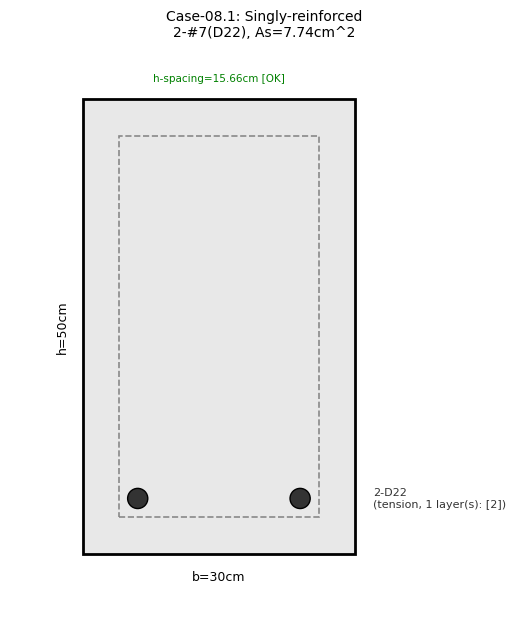

[PASS] 排筋間距檢查通過, 圖跟r['clear_spacing']=15.66cm一致


In [5]:
import os
if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
from rc_design import draw_rc_section

fig, ax = plt.subplots(figsize=(5.5,6.5))
# 斷面尺寸吃CASE, 鋼筋量吃r的實際回傳值——CASE改了, 這張圖自動跟著改
_, spacing_ok = draw_rc_section(
    b_cm=CASE['b_cm'], h_cm=CASE['h_cm'], cover_cm=CASE['cover'],
    layout=r['layout'],
    bar_diameter_cm=r['bar_d'],
    title=f"Case-08.1: Singly-reinforced\n{r['n_bars']}-{r['bar_size']}, As={r['As_provided']:.2f}cm^2",
    ax=ax
)
plt.tight_layout()
plt.show()

assert spacing_ok, "排筋間距應該通過(這是design_rebar()自己選筋時就檢查過的)"
print(f"[PASS] 排筋間距檢查通過, 圖跟r['clear_spacing']={r['clear_spacing']:.2f}cm一致")


## 第 6 課:完整設計例題——獨立一格,改幾個數字就能重複使用

前面幾課是逐步推導跟交叉驗證。這裡收一個**完全獨立**的範例格,不依賴
前面任何 cell 的變數——複製這一格出去,改開頭「題目條件」那幾行數字,
就能直接拿來設計另一根梁,不用回頭追前面的 `CASE`/`r` 是怎麼來的。

設計摘要: Case-08.1 矩形單筋梁撓曲設計

[幾何]
  b = 30.0 cm
  h = 50.0 cm
  cover = 4.0 cm
  有效深度 d = 43.80 cm

[材料]
  fc' = 280.0 kgf/cm^2
  fy = 4200.0 kgf/cm^2

[設計需求]
  設計彎矩 Mu = 112.5 kN-m

[選筋後實際供給]
  鋼筋: 2-#7(D22), As_provided = 7.742 cm^2

[合格判定]
  供給容量 = 119.17
  設計需求 = 112.50
  使用率(需求/供給) = 94.4%
  結論: 合格(供給 >= 需求)


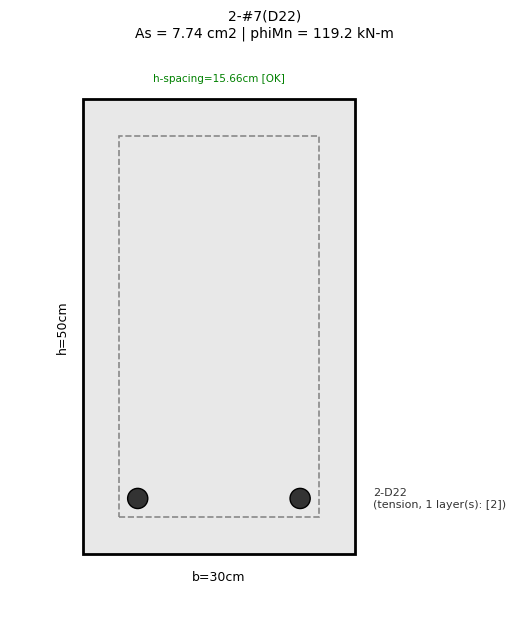

In [6]:
# ============================================================
# 完整設計例題：矩形單筋梁
# ============================================================
import os
import matplotlib.pyplot as plt

if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py

from rc_design import design_rebar, draw_rc_section, print_design_summary

# ---------- 題目條件（你可以改這些數字）----------
b_cm      = 30.0      # 梁寬 (cm)
h_cm      = 50.0      # 梁高 (cm)
cover     = 4.0       # 保護層 (cm)
fc        = 280.0     # 混凝土抗壓強度 (kgf/cm^2)
fy        = 4200.0    # 鋼筋降伏強度 (kgf/cm^2)
Mu_kNm    = 112.5     # 設計彎矩需求 (kN-m)  <- 需求強度

# ---------- 執行設計 ----------
r = design_rebar(
    Mu_kNm=Mu_kNm,
    b_cm=b_cm,
    h_cm=h_cm,
    cover=cover,
    fc=fc,
    fy=fy
)

# ---------- 印出完整設計摘要（像正式題目答案）----------
print_design_summary(
    kind="Case-08.1 矩形單筋梁撓曲設計",
    geometry={
        "b": f"{b_cm} cm",
        "h": f"{h_cm} cm",
        "cover": f"{cover} cm",
        "有效深度 d": f"{r['d']:.2f} cm"
    },
    material={
        "fc'": f"{fc} kgf/cm^2",
        "fy": f"{fy} kgf/cm^2"
    },
    demand={
        "設計彎矩 Mu": f"{Mu_kNm} kN-m"
    },
    result=r,
    capacity_key="phiMn_provided",
    demand_key="Mu_demand"
)

# ---------- 畫斷面配筋圖 ----------
fig, ax = plt.subplots(figsize=(5.5, 6.5))
draw_rc_section(
    b_cm=b_cm,
    h_cm=h_cm,
    cover_cm=cover,
    layout=r['layout'],
    bar_diameter_cm=r['bar_d'],
    title=f"{r['n_bars']}-{r['bar_size']}\nAs = {r['As_provided']:.2f} cm2 | phiMn = {r['phiMn_provided']:.1f} kN-m",
    ax=ax
)
plt.tight_layout()
plt.show()

### 換一組廠商指定的鋼筋規格

實務上很多公司只備料特定幾種規格,不是規範表列的 #5~#10 全都有。
`design_rebar()` 的 `bar_table` 參數可以直接傳自訂的鋼筋表——同一題,
換成假設某公司只有 #4、#6、#8 三種:

In [7]:
# 自訂鋼筋表: 只列公司實際備料的規格(格式: 名稱: (單根面積cm^2, 直徑cm))
company_bar_table = {
    "#4(D13)": (1.267, 1.27),
    "#6(D19)": (2.865, 1.91),
    "#8(D25)": (5.067, 2.54),
}

r_company = design_rebar(
    Mu_kNm=Mu_kNm, b_cm=b_cm, h_cm=h_cm, cover=cover, fc=fc, fy=fy,
    bar_table=company_bar_table
)

print(f"標準表(#5~#10全開放): {r['n_bars']}-{r['bar_size']}, As={r['As_provided']:.2f}cm^2")
print(f"公司限定表(僅#4/#6/#8): {r_company['n_bars']}-{r_company['bar_size']}, "
      f"As={r_company['As_provided']:.2f}cm^2")
print(f"\n供給容量: 標準表phiMn={r['phiMn_provided']:.1f}, "
      f"公司限定表phiMn={r_company['phiMn_provided']:.1f} (都>=需求{Mu_kNm}, 兩者都合格,"
      f" 只是用料量不同)")

標準表(#5~#10全開放): 2-#7(D22), As=7.74cm^2
公司限定表(僅#4/#6/#8): 3-#6(D19), As=8.60cm^2

供給容量: 標準表phiMn=119.2, 公司限定表phiMn=131.5 (都>=需求112.5, 兩者都合格, 只是用料量不同)


## 小結

- `design_rebar()` 正式收斂完成,含:規範強度公式、最小鋼筋比、拉力
  控制檢核、選筋(含排筋間距檢核)——之後 Case-08.2 起會延伸雙筋梁、
  T形梁,08.8 會接回 `case03_7` 取代固定的 `rho=0.02` 假設。
- 這一步的交叉驗證跟之前 fiber section vs 應變相容法的驗證**性質不同**:
  這裡兩個方法理論上該完全相等(同一個力學模型的兩種解法),對不上就是
  bug;fiber vs 應變相容法那次是兩個**不同材料模型假設**,允許有合理
  差異。兩種"疊圖對不對得起來"的判斷標準不能混為一談。